# Learned NEF Integrator

Learn an NEF-style neural integrator recurrence with nengo-dl.

This example compares two trainable neural integrators against a fixed
Neural Engineering Framework (NEF) reference:

1. random initialization
2. NEF initialization plus noise

Both trainable networks learn only the input and recurrent connection weights.
The training distribution emphasizes pulse-and-hold behaviour so the networks
must learn both accumulation and memory.

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import torch

import nengo
import nengo_dl

## Reproducibility

In [2]:
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
rng = np.random.RandomState(seed)

## Helper Functions and Parameter Initializations

In [ ]:
dt = 0.01
tau = 0.1
n_steps = 150

n_input_neurons = 80
n_integrator_neurons = 120
radius = 1.6

n_train = 512
n_val = 128
n_test = 128
mini = 32
epochs = 60
use_lr_scheduler = False

line_styles = {
    "ideal": dict(color="black", linestyle="-", marker="o", markevery=12, linewidth=2.0),
    "reference": dict(color="#1f77b4", linestyle="--", marker="x", markevery=12, linewidth=2.0),
    "random_pre": dict(color="#ff7f0e", linestyle="-.", marker="s", markevery=12, linewidth=1.8),
    "random_post": dict(color="#d62728", linestyle="-", marker="^", markevery=12, linewidth=2.2),
    "nef_pre": dict(color="#2ca02c", linestyle="-.", marker="D", markevery=12, linewidth=1.8),
    "nef_post": dict(color="#9467bd", linestyle="-", marker="v", markevery=12, linewidth=2.2),
    "control": dict(color="0.35", linestyle="-", marker="|", markevery=10, linewidth=1.4),
}


def generate_pulse_hold_inputs(n_samples, n_steps, rng, scale=1.0):
    """Return random pulses followed by a zero-input hold period."""

    x = np.zeros((n_samples, n_steps, 1), dtype=np.float32)
    for i in range(n_samples):
        onset = int(rng.randint(0, max(1, n_steps // 8)))
        width = int(rng.randint(8, 20))
        amp = float(rng.uniform(-scale, scale))
        x[i, onset : min(n_steps, onset + width), 0] = amp

        if rng.rand() < 0.35:
            gap = int(rng.randint(4, 16))
            onset_2 = onset + width + gap
            if onset_2 < n_steps - 8:
                width_2 = int(rng.randint(6, 16))
                amp_2 = float(rng.uniform(-scale, scale))
                x[i, onset_2 : min(n_steps, onset_2 + width_2), 0] = amp_2
    return x


def ideal_integrator_targets(x, dt):
    """Ideal discrete-time integration target."""

    return np.cumsum(x, axis=1, dtype=np.float32) * np.float32(dt)


def cosine_similarity(a, b):
    a_flat = a.reshape(-1)
    b_flat = b.reshape(-1)
    denom = np.linalg.norm(a_flat) * np.linalg.norm(b_flat)
    if denom < 1e-12:
        return np.nan
    return float(np.dot(a_flat, b_flat) / denom)


def pearson_correlation(a, b):
    a_flat = a.reshape(-1).astype(np.float64)
    b_flat = b.reshape(-1).astype(np.float64)
    a_centered = a_flat - np.mean(a_flat)
    b_centered = b_flat - np.mean(b_flat)
    denom = np.linalg.norm(a_centered) * np.linalg.norm(b_centered)
    if denom < 1e-12:
        return np.nan
    return float(np.dot(a_centered, b_centered) / denom)


def rankdata(x):
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(x), dtype=np.float64)
    return ranks


def spearman_correlation(a, b):
    return pearson_correlation(rankdata(a.reshape(-1)), rankdata(b.reshape(-1)))


def weight_similarity_stats(reference, learned):
    ref = reference.reshape(-1).astype(np.float64)
    cur = learned.reshape(-1).astype(np.float64)
    design = np.stack([ref, np.ones_like(ref)], axis=1)
    coeffs, _, _, _ = np.linalg.lstsq(design, cur[:, None], rcond=None)
    return {
        "pearson": pearson_correlation(ref, cur),
        "spearman": spearman_correlation(ref, cur),
        "cosine": cosine_similarity(ref, cur),
        "sign_agreement": float(np.mean(np.sign(ref) == np.sign(cur))),
        "slope": float(coeffs[0, 0]),
        "intercept": float(coeffs[1, 0]),
    }


def squeeze_weight_array(x):
    x = np.asarray(x)
    if x.ndim == 3 and x.shape[0] >= 1:
        return x[0]
    return x


def fit_recurrence_coeffs(u, x):
    """Fit x[t+1] ~= a * x[t] + b * u[t] by least squares."""

    design = np.concatenate(
        [x[:, :-1, 0].reshape(-1, 1), u[:, :-1, 0].reshape(-1, 1)],
        axis=1,
    )
    target = x[:, 1:, 0].reshape(-1, 1)
    coeffs, _, _, _ = np.linalg.lstsq(design, target, rcond=None)
    return float(coeffs[0, 0]), float(coeffs[1, 0])


def connection_weight_param(sim, conn):
    sig = sim._model.sig[conn]["weights"]
    param = sim.tensor_graph.signals.get_parameter(sig)
    if param is None:
        raise RuntimeError(f"No trainable parameter found for {conn}.")
    return param


def make_pulse_signal(segments, dt, total_steps):
    """Build a single control signal from (value, duration_ms) segments."""

    signal = []
    for value, duration_ms in segments:
        n_seg_steps = int(round((duration_ms / 1000.0) / dt))
        signal.extend([value] * n_seg_steps)
    signal = np.asarray(signal[:total_steps], dtype=np.float32)
    if signal.shape[0] < total_steps:
        signal = np.pad(signal, (0, total_steps - signal.shape[0]))
    return signal.reshape(1, total_steps, 1)


def make_integrator_network(trainable, seed_offset=0):
    """Construct a one-dimensional neural integrator."""

    with nengo.Network(label="Learned Integrator", seed=seed + seed_offset) as net:
        nengo_dl.configure_settings(trainable=True, stateful=False, keep_history=True)
        net.config[nengo.Ensemble].trainable = False
        net.config[nengo.Node].trainable = False

        stim = nengo.Node(np.zeros(1))

        input_pop = nengo.Ensemble(
            n_input_neurons,
            dimensions=1,
            neuron_type=nengo.LIFRate(),
            max_rates=nengo.dists.Uniform(80, 120),
            intercepts=nengo.dists.Uniform(-0.8, 0.8),
            seed=11,
        )

        integrator = nengo.Ensemble(
            n_integrator_neurons,
            dimensions=1,
            radius=radius,
            neuron_type=nengo.LIFRate(),
            max_rates=nengo.dists.Uniform(80, 120),
            intercepts=nengo.dists.Uniform(-0.8, 0.8),
            seed=22,
        )

        conn_stim = nengo.Connection(stim, input_pop, synapse=None)
        net.config[conn_stim].trainable = False

        conn_in = nengo.Connection(input_pop, integrator, transform=tau, synapse=tau)
        conn_rec = nengo.Connection(integrator, integrator, transform=1.0, synapse=tau)

        net.config[conn_in].trainable = trainable
        net.config[conn_rec].trainable = trainable

        p_integrator = nengo.Probe(integrator, synapse=None)

    return net, stim, conn_in, conn_rec, p_integrator


def initialize_params(params, init_mode, ref_tensors, init_rng):
    with torch.no_grad():
        for param, ref in zip(params, ref_tensors):
            scale = np.std(ref)
            if init_mode == "random":
                init = (0.1 * scale * init_rng.standard_normal(size=ref.shape)).astype(np.float32)
            elif init_mode == "nef_noisy":
                noise = (0.1 * scale * init_rng.standard_normal(size=ref.shape)).astype(np.float32)
                init = ref + noise
            else:
                raise ValueError(f"Unknown init_mode: {init_mode}")
            param.copy_(torch.tensor(init, dtype=param.dtype, device=param.device))


def simulate_trace(net, stim, probe, weights, x_input, n_steps, dt, seed):
    with nengo_dl.Simulator(net, dt=dt, minibatch_size=1, seed=seed) as sim:
        sim.compile(
            optimizer=torch.optim.Adam(sim.trainable_params(), lr=1e-3),
            loss={probe: "mse"},
        )
        sim.set_weights(weights)
        return sim.predict(x={stim: x_input}, n_steps=n_steps, batch_size=1)[probe]


def train_experiment(
    label,
    init_mode,
    train_x,
    train_y,
    val_x,
    val_y,
    test_x,
    test_y,
    plot_x,
    pulse_cases,
    ref_input_w,
    ref_rec_w,
    ref_test_y,
    use_scheduler=False,
    init_seed=0,
):
    net, stim, conn_in, conn_rec, p_integrator = make_integrator_network(
        trainable=True, seed_offset=0
    )

    base_lr = 1e-5
    min_lr = 1e-6

    with nengo_dl.Simulator(net, dt=dt, minibatch_size=mini, seed=seed) as sim:
        params = [connection_weight_param(sim, conn_in), connection_weight_param(sim, conn_rec)]
        optimizer = torch.optim.Adam(params, lr=base_lr)
        sim.compile(optimizer=optimizer, loss={p_integrator: "mse"})
        scheduler = None
        if use_scheduler:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs, eta_min=min_lr
            )

        init_rng = np.random.RandomState(init_seed)
        initialize_params(params, init_mode, [ref_input_w, ref_rec_w], init_rng)

        pre_test = sim.predict(x={stim: test_x}, n_steps=n_steps, batch_size=mini)[p_integrator]
        pre_mse = float(np.mean((pre_test - test_y) ** 2))
        pre_weights = sim.get_weights()

        history = {"loss": [], "val_mse": [], "lr": []}
        best_val_mse = np.inf
        best_weights = sim.get_weights()

        for epoch in range(epochs):
            current_lr = optimizer.param_groups[0]["lr"]
            fit_result = sim.fit(
                x={stim: train_x},
                y={p_integrator: train_y},
                n_steps=n_steps,
                epochs=1,
                batch_size=mini,
                shuffle=True,
                verbose=0,
            )
            train_loss = float(fit_result["loss"][-1])
            val_pred = sim.predict(x={stim: val_x}, n_steps=n_steps, batch_size=mini)[p_integrator]
            val_mse = float(np.mean((val_pred - val_y) ** 2))
            history["loss"].append(train_loss)
            history["val_mse"].append(val_mse)
            history["lr"].append(current_lr)
            print(
                f"{label} epoch {epoch + 1:02d}/{epochs} "
                f"lr={current_lr:.2e} loss={train_loss:.5f} val_mse={val_mse:.5f}"
            )
            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_weights = sim.get_weights()
            if scheduler is not None:
                scheduler.step()

        sim.set_weights(best_weights)
        post_test = sim.predict(x={stim: test_x}, n_steps=n_steps, batch_size=mini)[p_integrator]
        post_weights = sim.get_weights()
        post_params = sim.get_nengo_params([conn_in, conn_rec])

    pre_plot = simulate_trace(net, stim, p_integrator, pre_weights, plot_x, n_steps, dt, seed)
    post_plot = simulate_trace(net, stim, p_integrator, post_weights, plot_x, n_steps, dt, seed)

    post_input_w = squeeze_weight_array(post_params[conn_in]["weights"])
    post_rec_w = squeeze_weight_array(post_params[conn_rec]["weights"])

    pulse_steps = 120
    pulse_time = np.arange(pulse_steps) * dt
    pulse_results = []
    with nengo_dl.Simulator(net, dt=dt, minibatch_size=1, seed=seed) as sim:
        sim.compile(
            optimizer=torch.optim.Adam(sim.trainable_params(), lr=1e-3),
            loss={p_integrator: "mse"},
        )
        sim.set_weights(post_weights)
        for pulse_label, segments in pulse_cases:
            case_x = make_pulse_signal(segments, dt, pulse_steps)
            ideal_case_y = ideal_integrator_targets(case_x, dt)
            learned_case_y = sim.predict(x={stim: case_x}, n_steps=pulse_steps, batch_size=1)[
                p_integrator
            ]
            pulse_results.append(
                {
                    "label": pulse_label,
                    "x": case_x[0, :, 0],
                    "ideal": ideal_case_y[0, :, 0],
                    "learned": np.asarray(learned_case_y).reshape(-1),
                    "expected_hold": float(ideal_case_y[0, -1, 0]),
                    "learned_hold": float(np.asarray(learned_case_y).reshape(-1)[-1]),
                }
            )

    pre_a, pre_b = fit_recurrence_coeffs(test_x, pre_test)
    post_a, post_b = fit_recurrence_coeffs(test_x, post_test)
    return {
        "label": label,
        "init_mode": init_mode,
        "net": net,
        "stim": stim,
        "probe": p_integrator,
        "history": history,
        "pre_test": pre_test,
        "post_test": post_test,
        "pre_plot": pre_plot,
        "post_plot": post_plot,
        "pre_mse_vs_ideal": pre_mse,
        "post_mse_vs_ideal": float(np.mean((post_test - test_y) ** 2)),
        "pre_mse_vs_ref": float(np.mean((pre_test - ref_test_y) ** 2)),
        "post_mse_vs_ref": float(np.mean((post_test - ref_test_y) ** 2)),
        "post_input_w": post_input_w,
        "post_rec_w": post_rec_w,
        "input_stats": weight_similarity_stats(ref_input_w, post_input_w),
        "rec_stats": weight_similarity_stats(ref_rec_w, post_rec_w),
        "pre_recurrence": (pre_a, pre_b),
        "post_recurrence": (post_a, post_b),
        "pulse_results": pulse_results,
        "pulse_time": pulse_time,
    }

def train_experiment_with_weight_decay(
    label,
    init_mode,
    train_x,
    train_y,
    val_x,
    val_y,
    test_x,
    test_y,
    plot_x,
    pulse_cases,
    ref_input_w,
    ref_rec_w,
    ref_test_y,
    weight_decay=0.0,
    use_scheduler=False,
    init_seed=0,
):
    net, stim, conn_in, conn_rec, p_integrator = make_integrator_network(
        trainable=True, seed_offset=0
    )

    base_lr = 1e-5
    min_lr = 1e-6

    with nengo_dl.Simulator(net, dt=dt, minibatch_size=mini, seed=seed) as sim:
        params = [connection_weight_param(sim, conn_in), connection_weight_param(sim, conn_rec)]
        optimizer = torch.optim.Adam(params, lr=base_lr, weight_decay=weight_decay)
        sim.compile(optimizer=optimizer, loss={p_integrator: 'mse'})
        scheduler = None
        if use_scheduler:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs, eta_min=min_lr
            )

        init_rng = np.random.RandomState(init_seed)
        initialize_params(params, init_mode, [ref_input_w, ref_rec_w], init_rng)

        pre_test = sim.predict(x={stim: test_x}, n_steps=n_steps, batch_size=mini)[p_integrator]
        pre_mse = float(np.mean((pre_test - test_y) ** 2))
        pre_weights = sim.get_weights()

        history = {'loss': [], 'val_mse': [], 'lr': []}
        best_val_mse = np.inf
        best_weights = sim.get_weights()

        for epoch in range(epochs):
            current_lr = optimizer.param_groups[0]['lr']
            fit_result = sim.fit(
                x={stim: train_x},
                y={p_integrator: train_y},
                n_steps=n_steps,
                epochs=1,
                batch_size=mini,
                shuffle=True,
                verbose=0,
            )
            train_loss = float(fit_result['loss'][-1])
            val_pred = sim.predict(x={stim: val_x}, n_steps=n_steps, batch_size=mini)[p_integrator]
            val_mse = float(np.mean((val_pred - val_y) ** 2))
            history['loss'].append(train_loss)
            history['val_mse'].append(val_mse)
            history['lr'].append(current_lr)
            print(
                f'{label} epoch {epoch + 1:02d}/{epochs} ' +
                f'lr={current_lr:.2e} wd={weight_decay:.2e} ' +
                f'loss={train_loss:.5f} val_mse={val_mse:.5f}'
            )
            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_weights = sim.get_weights()
            if scheduler is not None:
                scheduler.step()

        sim.set_weights(best_weights)
        post_test = sim.predict(x={stim: test_x}, n_steps=n_steps, batch_size=mini)[p_integrator]
        post_weights = sim.get_weights()
        post_params = sim.get_nengo_params([conn_in, conn_rec])

    pre_plot = simulate_trace(net, stim, p_integrator, pre_weights, plot_x, n_steps, dt, seed)
    post_plot = simulate_trace(net, stim, p_integrator, post_weights, plot_x, n_steps, dt, seed)

    post_input_w = squeeze_weight_array(post_params[conn_in]['weights'])
    post_rec_w = squeeze_weight_array(post_params[conn_rec]['weights'])

    pulse_steps = 120
    pulse_time = np.arange(pulse_steps) * dt
    pulse_results = []
    with nengo_dl.Simulator(net, dt=dt, minibatch_size=1, seed=seed) as sim:
        sim.compile(
            optimizer=torch.optim.Adam(sim.trainable_params(), lr=1e-3),
            loss={p_integrator: 'mse'},
        )
        sim.set_weights(post_weights)
        for pulse_label, segments in pulse_cases:
            case_x = make_pulse_signal(segments, dt, pulse_steps)
            ideal_case_y = ideal_integrator_targets(case_x, dt)
            learned_case_y = sim.predict(x={stim: case_x}, n_steps=pulse_steps, batch_size=1)[p_integrator]
            pulse_results.append({
                'label': pulse_label,
                'x': case_x[0, :, 0],
                'ideal': ideal_case_y[0, :, 0],
                'learned': np.asarray(learned_case_y).reshape(-1),
                'expected_hold': float(ideal_case_y[0, -1, 0]),
                'learned_hold': float(np.asarray(learned_case_y).reshape(-1)[-1]),
            })

    pre_a, pre_b = fit_recurrence_coeffs(test_x, pre_test)
    post_a, post_b = fit_recurrence_coeffs(test_x, post_test)
    return {
        'label': label,
        'init_mode': init_mode,
        'weight_decay': weight_decay,
        'history': history,
        'pre_test': pre_test,
        'post_test': post_test,
        'pre_plot': pre_plot,
        'post_plot': post_plot,
        'pre_mse_vs_ideal': pre_mse,
        'post_mse_vs_ideal': float(np.mean((post_test - test_y) ** 2)),
        'pre_mse_vs_ref': float(np.mean((pre_test - ref_test_y) ** 2)),
        'post_mse_vs_ref': float(np.mean((post_test - ref_test_y) ** 2)),
        'post_input_w': post_input_w,
        'post_rec_w': post_rec_w,
        'input_stats': weight_similarity_stats(ref_input_w, post_input_w),
        'rec_stats': weight_similarity_stats(ref_rec_w, post_rec_w),
        'pre_recurrence': (pre_a, pre_b),
        'post_recurrence': (post_a, post_b),
        'pulse_results': pulse_results,
        'pulse_time': pulse_time,
    }

## 1. Generate training and test data

In [4]:
train_x = generate_pulse_hold_inputs(n_train, n_steps, rng, scale=1.0)
val_x = generate_pulse_hold_inputs(n_val, n_steps, rng, scale=1.0)
test_x = generate_pulse_hold_inputs(n_test, n_steps, rng, scale=1.0)

ideal_train_y = ideal_integrator_targets(train_x, dt)
ideal_val_y = ideal_integrator_targets(val_x, dt)
ideal_test_y = ideal_integrator_targets(test_x, dt)

plot_x = make_pulse_signal(
    [(0.8, 120), (0.0, 160), (-0.6, 100), (0.0, 1120)],
    dt,
    n_steps,
)
plot_y = ideal_integrator_targets(plot_x, dt)

print(f"Train inputs: {train_x.shape}  ideal targets: {ideal_train_y.shape}")
print(f"Val   inputs: {val_x.shape}   ideal targets: {ideal_val_y.shape}")
print(f"Test  inputs: {test_x.shape}   ideal targets: {ideal_test_y.shape}")
print("Training distribution: random pulses followed by zero-input hold periods")
print(f"Learning rate scheduler enabled: {use_lr_scheduler}")

Train inputs: (512, 150, 1)  ideal targets: (512, 150, 1)
Val   inputs: (128, 150, 1)   ideal targets: (128, 150, 1)
Test  inputs: (128, 150, 1)   ideal targets: (128, 150, 1)
Training distribution: random pulses followed by zero-input hold periods
Learning rate scheduler enabled: False


## 2. Build the fixed NEF reference integrator

In [5]:
ref_net, ref_stim, ref_in, ref_rec, ref_p_integrator = make_integrator_network(
    trainable=False, seed_offset=0
)

with nengo_dl.Simulator(ref_net, dt=dt, minibatch_size=mini, seed=seed) as ref_sim:
    ref_test = ref_sim.predict(x={ref_stim: test_x}, n_steps=n_steps, batch_size=mini)
    ref_conn_params = ref_sim.get_nengo_params([ref_in, ref_rec])

with nengo_dl.Simulator(ref_net, dt=dt, minibatch_size=1, seed=seed) as ref_plot_sim:
    ref_plot = ref_plot_sim.predict(x={ref_stim: plot_x}, n_steps=n_steps, batch_size=1)

ref_test_y = ref_test[ref_p_integrator]
ref_plot_y = ref_plot[ref_p_integrator]
ref_input_w = squeeze_weight_array(ref_conn_params[ref_in]["weights"])
ref_rec_w = squeeze_weight_array(ref_conn_params[ref_rec]["weights"])
ref_mse = float(np.mean((ref_test_y - ideal_test_y) ** 2))
ref_a, ref_b = fit_recurrence_coeffs(test_x, ref_test_y)

print(f"Reference NEF test MSE vs ideal target: {ref_mse:.6f}")
print(f"Reference recurrence fit: x[t+1] ~= {ref_a:.4f} * x[t] + {ref_b:.4f} * u[t]")

Reference NEF test MSE vs ideal target: 0.000883
Reference recurrence fit: x[t+1] ~= 1.0029 * x[t] + 0.0098 * u[t]


## 3. Train both learned variants

In [6]:
pulse_cases = [
    ("+1 for 100 ms, then hold", [(1.0, 100), (0.0, 400)]),
    ("-1 for 100 ms, then hold", [(-1.0, 100), (0.0, 400)]),
    ("+1 then -1 with long hold", [(1.0, 100), (0.0, 100), (-1.0, 100), (0.0, 200)]),
    ("+0.5 for 200 ms, then hold", [(0.5, 200), (0.0, 300)]),
]

results = [
    train_experiment(
        label="Random init",
        init_mode="random",
        train_x=train_x,
        train_y=ideal_train_y,
        val_x=val_x,
        val_y=ideal_val_y,
        test_x=test_x,
        test_y=ideal_test_y,
        plot_x=plot_x,
        pulse_cases=pulse_cases,
        ref_input_w=ref_input_w,
        ref_rec_w=ref_rec_w,
        ref_test_y=ref_test_y,
        use_scheduler=use_lr_scheduler,
        init_seed=seed + 101,
    ),
    train_experiment(
        label="Noisy NEF init",
        init_mode="nef_noisy",
        train_x=train_x,
        train_y=ideal_train_y,
        val_x=val_x,
        val_y=ideal_val_y,
        test_x=test_x,
        test_y=ideal_test_y,
        plot_x=plot_x,
        pulse_cases=pulse_cases,
        ref_input_w=ref_input_w,
        ref_rec_w=ref_rec_w,
        ref_test_y=ref_test_y,
        use_scheduler=use_lr_scheduler,
        init_seed=seed + 202,
    ),
]

for result in results:
    pre_a, pre_b = result["pre_recurrence"]
    post_a, post_b = result["post_recurrence"]
    print(f"\n{result['label']}")
    print("-" * len(result["label"]))
    print(f"Pre-train MSE vs ideal:  {result['pre_mse_vs_ideal']:.6f}")
    print(f"Post-train MSE vs ideal: {result['post_mse_vs_ideal']:.6f}")
    print(f"Pre-train recurrence:  x[t+1] ~= {pre_a:.4f} * x[t] + {pre_b:.4f} * u[t]")
    print(f"Post-train recurrence: x[t+1] ~= {post_a:.4f} * x[t] + {post_b:.4f} * u[t]")
    print(
        "Input weights:      "
        f"r={result['input_stats']['pearson']:.4f}, "
        f"rho={result['input_stats']['spearman']:.4f}, "
        f"cos={result['input_stats']['cosine']:.4f}, "
        f"sign={result['input_stats']['sign_agreement']:.2%}"
    )
    print(
        "Recurrent weights:  "
        f"r={result['rec_stats']['pearson']:.4f}, "
        f"rho={result['rec_stats']['spearman']:.4f}, "
        f"cos={result['rec_stats']['cosine']:.4f}, "
        f"sign={result['rec_stats']['sign_agreement']:.2%}"
    )
    print("Pulse-memory checks")
    for pulse_result in result["pulse_results"]:
        print(
            f"  {pulse_result['label']}: "
            f"expected={pulse_result['expected_hold']:.3f}, "
            f"learned={pulse_result['learned_hold']:.3f}"
        )

Random init epoch 01/60 lr=1.00e-05 loss=0.00732 val_mse=0.00595
Random init epoch 02/60 lr=1.00e-05 loss=0.00613 val_mse=0.00579
Random init epoch 03/60 lr=1.00e-05 loss=0.00577 val_mse=0.00572
Random init epoch 04/60 lr=1.00e-05 loss=0.00619 val_mse=0.00622
Random init epoch 05/60 lr=1.00e-05 loss=0.00602 val_mse=0.00602
Random init epoch 06/60 lr=1.00e-05 loss=0.00579 val_mse=0.00538
Random init epoch 07/60 lr=1.00e-05 loss=0.00546 val_mse=0.00550
Random init epoch 08/60 lr=1.00e-05 loss=0.00492 val_mse=0.00364
Random init epoch 09/60 lr=1.00e-05 loss=0.00454 val_mse=0.00393
Random init epoch 10/60 lr=1.00e-05 loss=0.00520 val_mse=0.00384
Random init epoch 11/60 lr=1.00e-05 loss=0.00354 val_mse=0.00319
Random init epoch 12/60 lr=1.00e-05 loss=0.00239 val_mse=0.03592
Random init epoch 13/60 lr=1.00e-05 loss=0.01729 val_mse=0.00654
Random init epoch 14/60 lr=1.00e-05 loss=0.00605 val_mse=0.00549
Random init epoch 15/60 lr=1.00e-05 loss=0.00514 val_mse=0.00502
Random init epoch 16/60 l

## 4. Visualise behaviour on a held-out signal

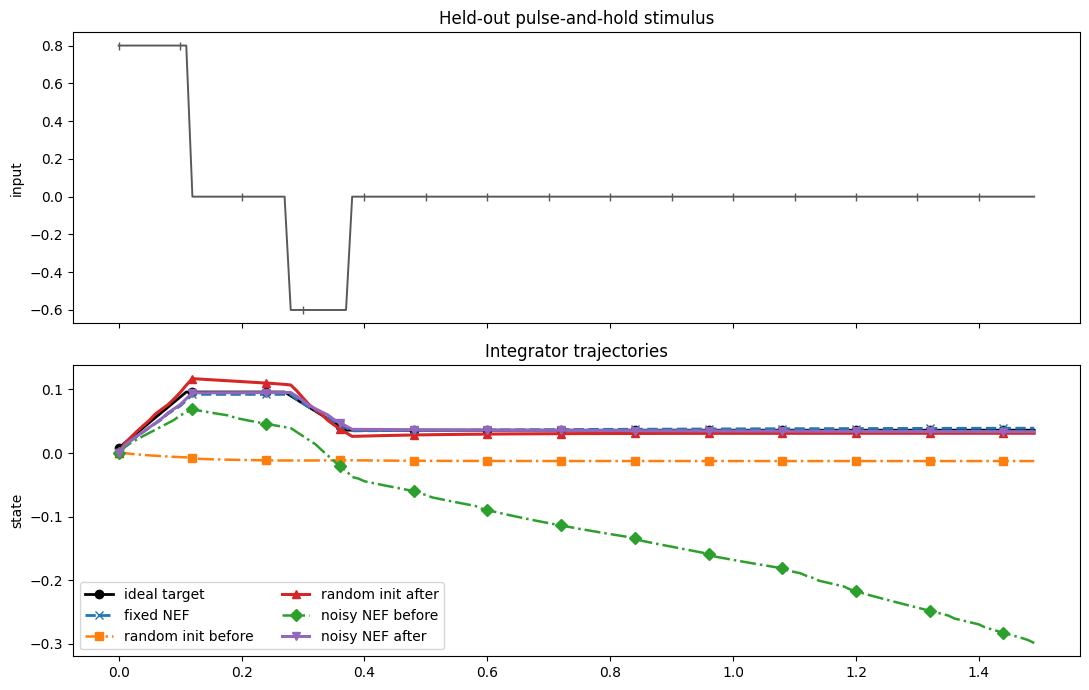

In [7]:
t = np.arange(n_steps) * dt
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t, plot_x[0, :, 0], **line_styles["control"])
axes[0].set_ylabel("input")
axes[0].set_title("Held-out pulse-and-hold stimulus")

axes[1].plot(t, plot_y[0, :, 0], label="ideal target", **line_styles["ideal"])
axes[1].plot(t, np.asarray(ref_plot_y).reshape(-1), label="fixed NEF", **line_styles["reference"])
axes[1].plot(
    t, np.asarray(results[0]["pre_plot"]).reshape(-1), label="random init before", **line_styles["random_pre"]
)
axes[1].plot(
    t, np.asarray(results[0]["post_plot"]).reshape(-1), label="random init after", **line_styles["random_post"]
)
axes[1].plot(
    t, np.asarray(results[1]["pre_plot"]).reshape(-1), label="noisy NEF before", **line_styles["nef_pre"]
)
axes[1].plot(
    t, np.asarray(results[1]["post_plot"]).reshape(-1), label="noisy NEF after", **line_styles["nef_post"]
)
axes[1].set_ylabel("state")
axes[1].set_title("Integrator trajectories")
axes[1].legend(loc="lower left", ncol=2)

plt.tight_layout()
plt.show()

## 5. Plot training curves

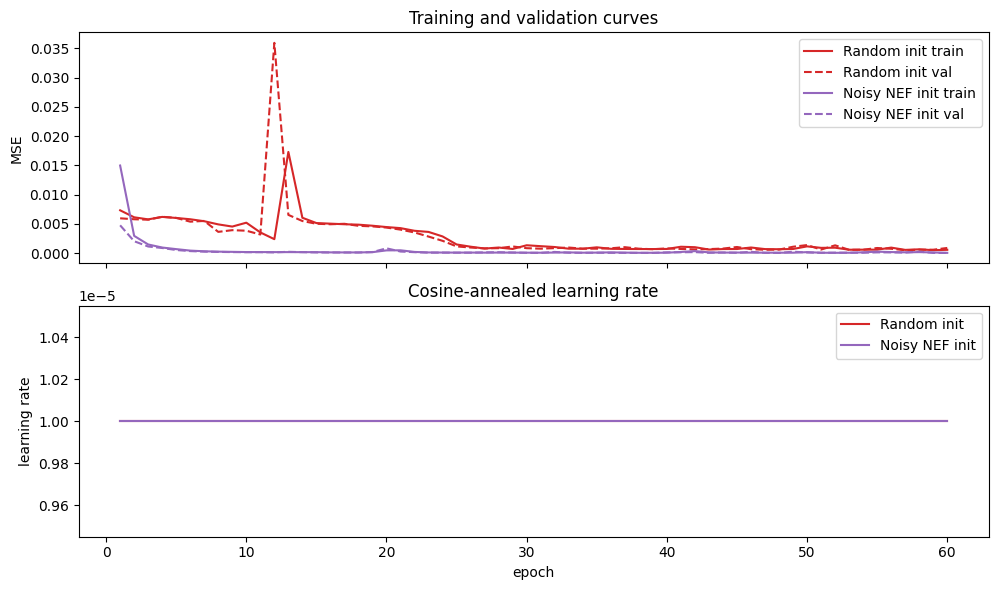

In [21]:
if use_lr_scheduler:
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for result, color in zip(results, ["#d62728", "#9467bd"]):
        epochs_axis = np.arange(1, epochs + 1)
        axes[0].plot(epochs_axis, result["history"]["loss"], label=f"{result['label']} train", color=color)
        axes[0].plot(
            epochs_axis,
            result["history"]["val_mse"],
            label=f"{result['label']} val",
            color=color,
            linestyle="--",
        )
        axes[1].plot(epochs_axis, result["history"]["lr"], label=result["label"], color=color)
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Training and validation curves")
    axes[0].legend(loc="upper right")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("learning rate")
    axes[1].set_title("Cosine-annealed learning rate")
    axes[1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for result, color in zip(results, ["#d62728", "#9467bd"]):
        epochs_axis = np.arange(1, epochs + 1)
        axes[0].plot(epochs_axis, result["history"]["loss"], label=f"{result['label']} train", color=color)
        axes[0].plot(
            epochs_axis,
            result["history"]["val_mse"],
            label=f"{result['label']} val",
            color=color,
            linestyle="--",
        )
        axes[1].plot(epochs_axis, result["history"]["lr"], label=result["label"], color=color)
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Training and validation curves")
    axes[0].legend(loc="upper right")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("learning rate")
    axes[1].set_title("Cosine-annealed learning rate")
    axes[1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## 6. Plot pulse-memory tests

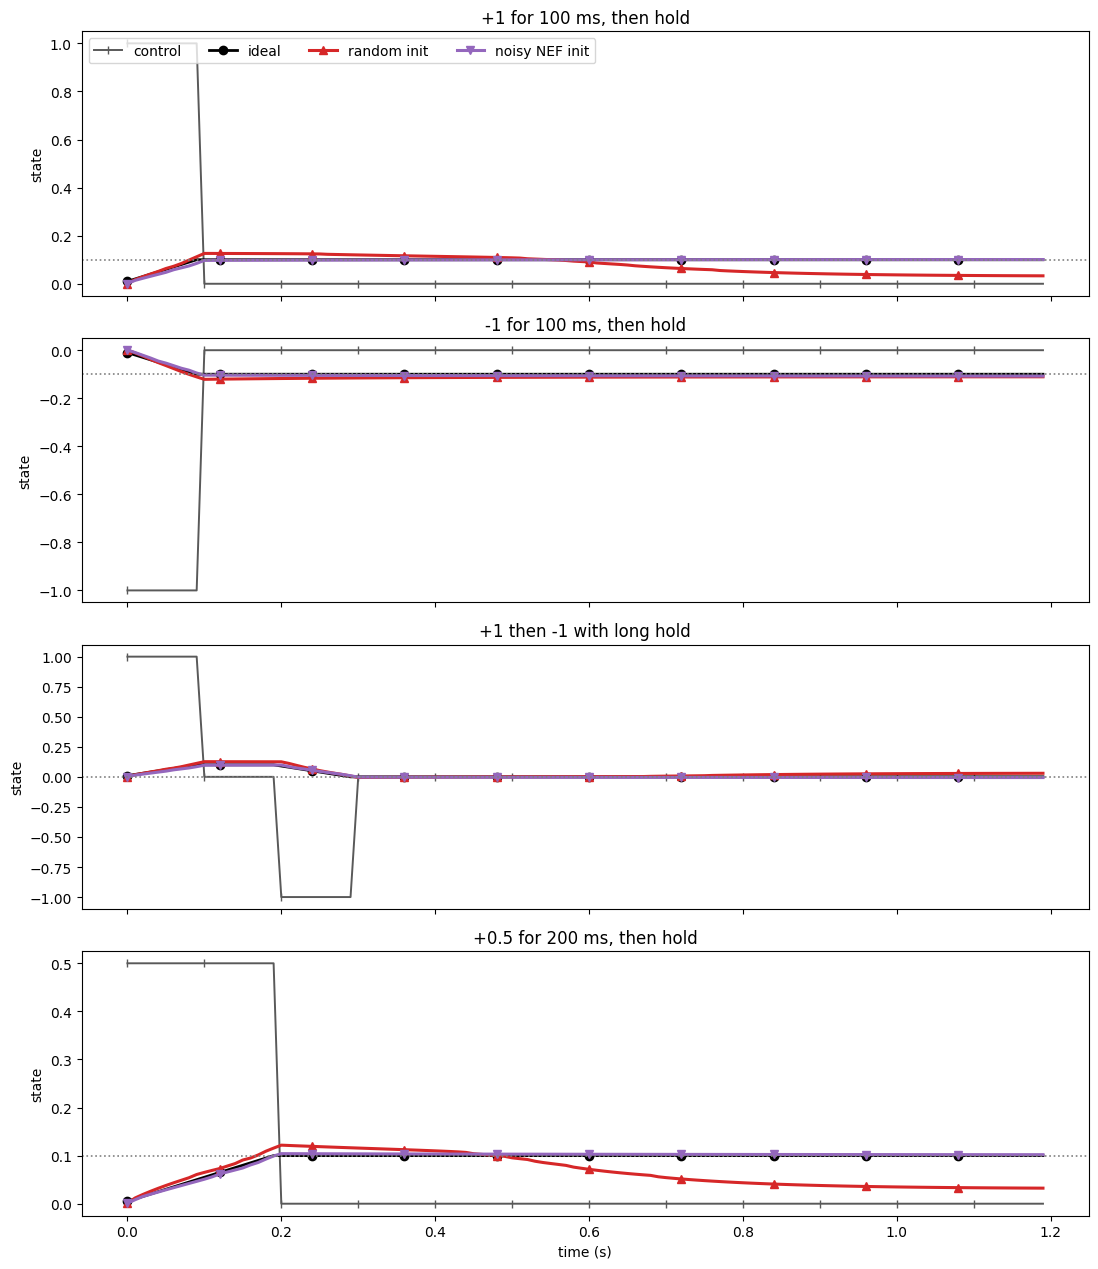

In [9]:
fig, axes = plt.subplots(len(pulse_cases), 1, figsize=(11, 3.2 * len(pulse_cases)), sharex=True)
if len(pulse_cases) == 1:
    axes = [axes]

for ax, case_index in zip(axes, range(len(pulse_cases))):
    ref_case_x = results[0]["pulse_results"][case_index]["x"]
    ref_case_ideal = results[0]["pulse_results"][case_index]["ideal"]
    ax.plot(results[0]["pulse_time"], ref_case_x, label="control", **line_styles["control"])
    ax.plot(results[0]["pulse_time"], ref_case_ideal, label="ideal", **line_styles["ideal"])
    ax.plot(
        results[0]["pulse_time"],
        results[0]["pulse_results"][case_index]["learned"],
        label="random init",
        **line_styles["random_post"],
    )
    ax.plot(
        results[1]["pulse_time"],
        results[1]["pulse_results"][case_index]["learned"],
        label="noisy NEF init",
        **line_styles["nef_post"],
    )
    ax.axhline(
        results[0]["pulse_results"][case_index]["expected_hold"],
        color="0.5",
        linestyle=":",
        linewidth=1.2,
    )
    ax.set_ylabel("state")
    ax.set_title(results[0]["pulse_results"][case_index]["label"])
axes[0].legend(loc="upper left", ncol=4)
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## 7. Inspect the recurrent weight statistics

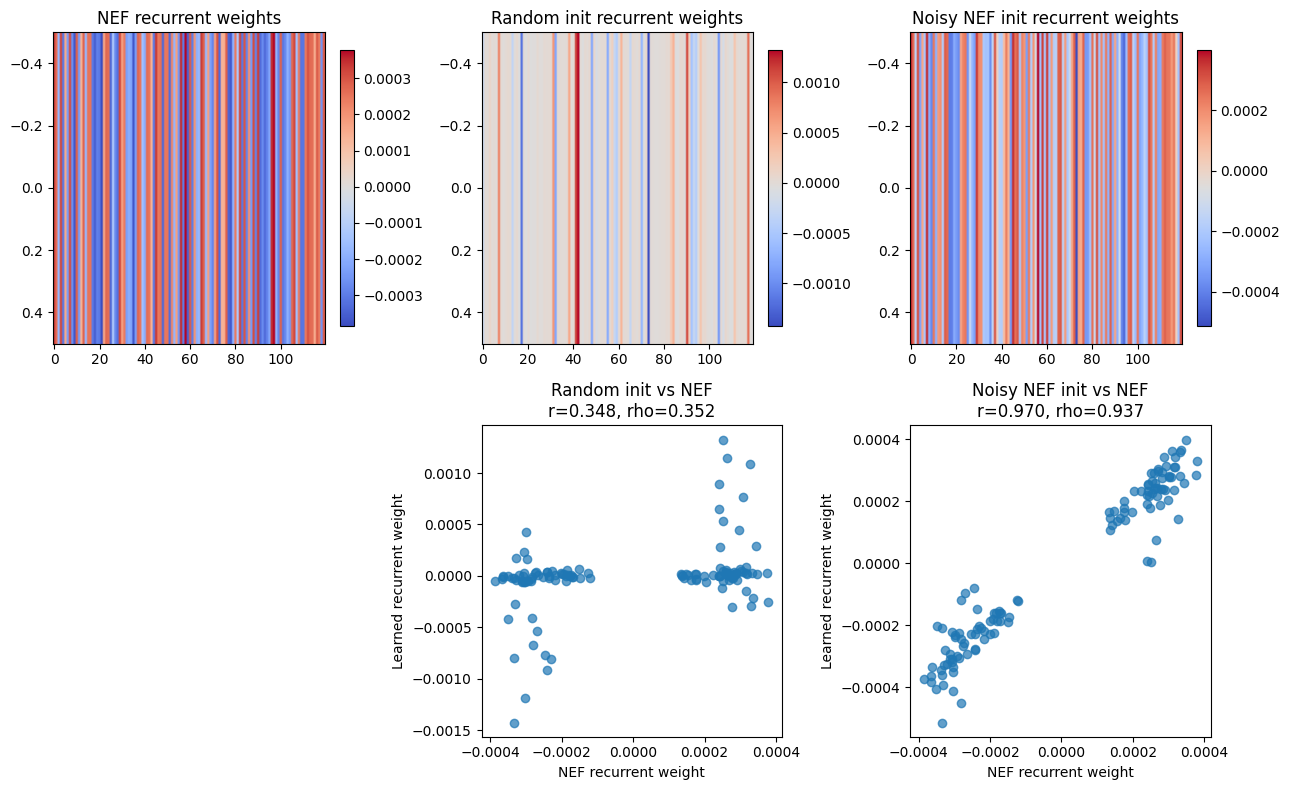

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

im0 = axes[0, 0].imshow(ref_rec_w, aspect="auto", cmap="coolwarm")
axes[0, 0].set_title("NEF recurrent weights")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

for col, result in enumerate(results, start=1):
    im = axes[0, col].imshow(result["post_rec_w"], aspect="auto", cmap="coolwarm")
    axes[0, col].set_title(f"{result['label']} recurrent weights")
    plt.colorbar(im, ax=axes[0, col], fraction=0.046)

axes[1, 0].axis("off")

axes[1, 1].scatter(ref_rec_w.reshape(-1), results[0]["post_rec_w"].reshape(-1), alpha=0.7)
axes[1, 1].set_title(
    "Random init vs NEF\n"
    f"r={results[0]['rec_stats']['pearson']:.3f}, rho={results[0]['rec_stats']['spearman']:.3f}"
)
axes[1, 1].set_xlabel("NEF recurrent weight")
axes[1, 1].set_ylabel("Learned recurrent weight")

axes[1, 2].scatter(ref_rec_w.reshape(-1), results[1]["post_rec_w"].reshape(-1), alpha=0.7)
axes[1, 2].set_title(
    "Noisy NEF init vs NEF\n"
    f"r={results[1]['rec_stats']['pearson']:.3f}, rho={results[1]['rec_stats']['spearman']:.3f}"
)
axes[1, 2].set_xlabel("NEF recurrent weight")
axes[1, 2].set_ylabel("Learned recurrent weight")

plt.tight_layout()
plt.show()

## 8. Weight Decay

Noisy NEF init + wd epoch 01/60 lr=1.00e-05 wd=1.00e-04 loss=0.01868 val_mse=0.00853
Noisy NEF init + wd epoch 02/60 lr=1.00e-05 wd=1.00e-04 loss=0.00380 val_mse=0.00205
Noisy NEF init + wd epoch 03/60 lr=1.00e-05 wd=1.00e-04 loss=0.00174 val_mse=0.00150
Noisy NEF init + wd epoch 04/60 lr=1.00e-05 wd=1.00e-04 loss=0.00119 val_mse=0.00102
Noisy NEF init + wd epoch 05/60 lr=1.00e-05 wd=1.00e-04 loss=0.00086 val_mse=0.00076
Noisy NEF init + wd epoch 06/60 lr=1.00e-05 wd=1.00e-04 loss=0.00063 val_mse=0.00054
Noisy NEF init + wd epoch 07/60 lr=1.00e-05 wd=1.00e-04 loss=0.00045 val_mse=0.00040
Noisy NEF init + wd epoch 08/60 lr=1.00e-05 wd=1.00e-04 loss=0.00037 val_mse=0.00033
Noisy NEF init + wd epoch 09/60 lr=1.00e-05 wd=1.00e-04 loss=0.00031 val_mse=0.00029
Noisy NEF init + wd epoch 10/60 lr=1.00e-05 wd=1.00e-04 loss=0.00028 val_mse=0.00026
Noisy NEF init + wd epoch 11/60 lr=1.00e-05 wd=1.00e-04 loss=0.00028 val_mse=0.00026
Noisy NEF init + wd epoch 12/60 lr=1.00e-05 wd=1.00e-04 loss=0.00

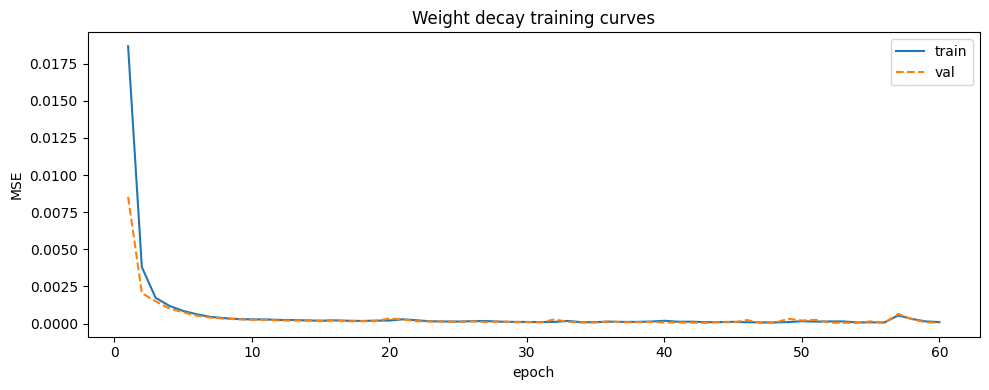

In [24]:
weight_decay = 1e-4

wd_result = train_experiment_with_weight_decay(
    label='Noisy NEF init + wd',
    init_mode='nef_noisy',
    train_x=train_x,
    train_y=ideal_train_y,
    val_x=val_x,
    val_y=ideal_val_y,
    test_x=test_x,
    test_y=ideal_test_y,
    plot_x=plot_x,
    pulse_cases=pulse_cases,
    ref_input_w=ref_input_w,
    ref_rec_w=ref_rec_w,
    ref_test_y=ref_test_y,
    weight_decay=weight_decay,
    use_scheduler=use_lr_scheduler,
    init_seed=seed + 303,
)

pre_a, pre_b = wd_result['pre_recurrence']
post_a, post_b = wd_result['post_recurrence']
print(f"Weight decay = {weight_decay:.2e}")
print(f"Pre-train MSE vs ideal:  {wd_result['pre_mse_vs_ideal']:.6f}")
print(f"Post-train MSE vs ideal: {wd_result['post_mse_vs_ideal']:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(np.arange(1, epochs + 1), wd_result['history']['loss'], label='train')
ax.plot(np.arange(1, epochs + 1), wd_result['history']['val_mse'], label='val', linestyle='--')
ax.set_title('Weight decay training curves')
ax.set_xlabel('epoch')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Weight Decay Pulse-Memory Plots

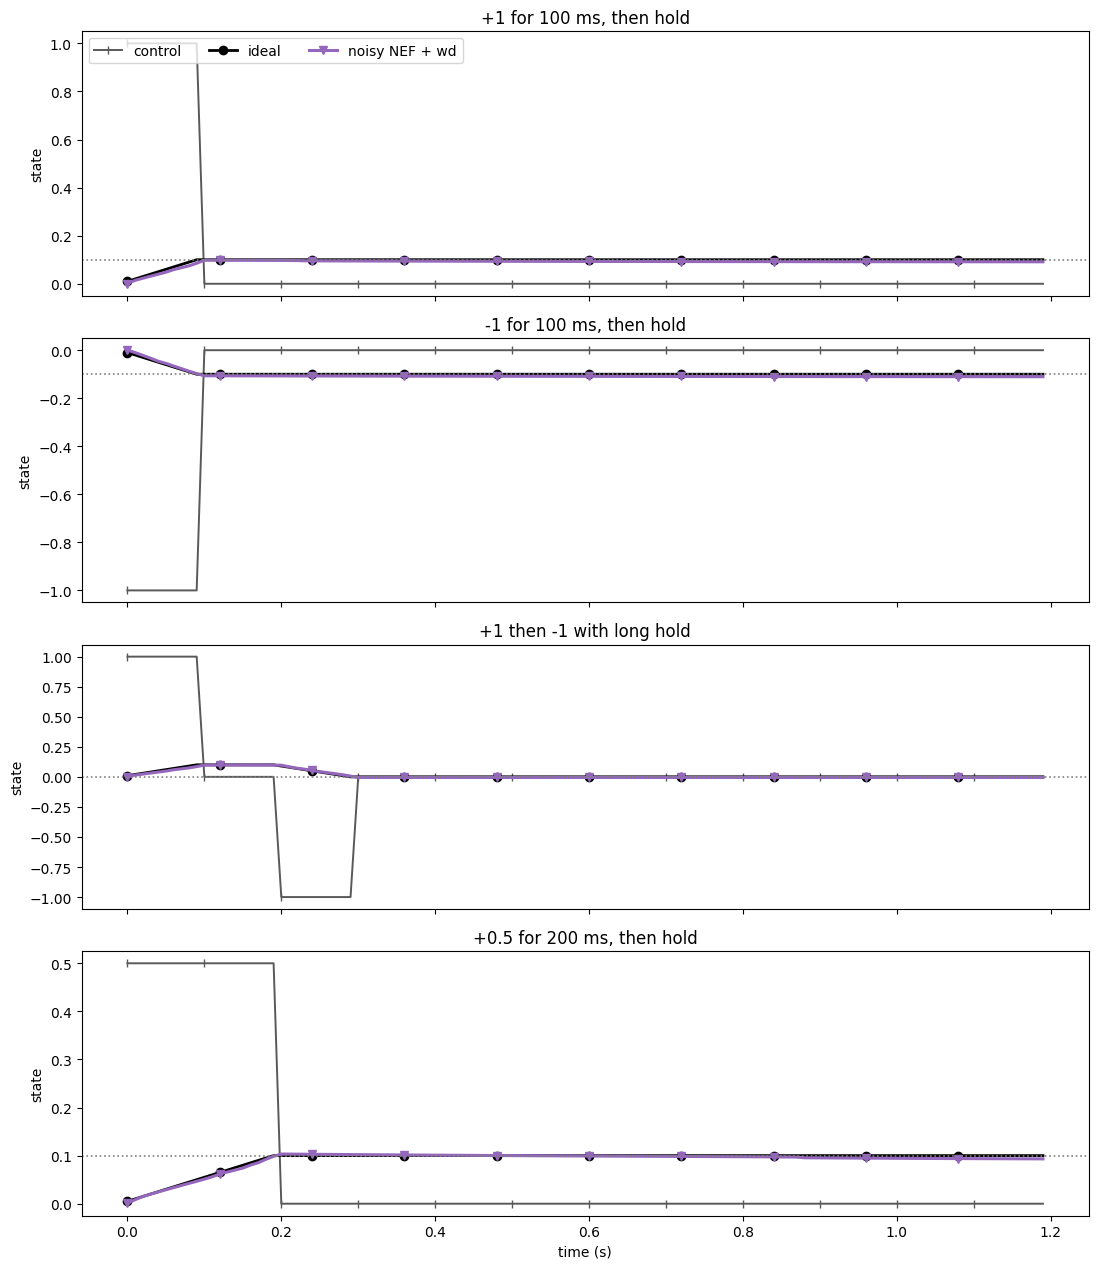

In [25]:
fig, axes = plt.subplots(len(pulse_cases), 1, figsize=(11, 3.2 * len(pulse_cases)), sharex=True)
if len(pulse_cases) == 1:
    axes = [axes]

for ax, case_index in zip(axes, range(len(pulse_cases))):
    wd_case_x = wd_result['pulse_results'][case_index]['x']
    wd_case_ideal = wd_result['pulse_results'][case_index]['ideal']
    ax.plot(wd_result['pulse_time'], wd_case_x, label='control', **line_styles['control'])
    ax.plot(wd_result['pulse_time'], wd_case_ideal, label='ideal', **line_styles['ideal'])
    ax.plot(
        wd_result['pulse_time'],
        wd_result['pulse_results'][case_index]['learned'],
        label='noisy NEF + wd',
        **line_styles['nef_post'],
    )
    ax.axhline(
        wd_result['pulse_results'][case_index]['expected_hold'],
        color='0.5',
        linestyle=':',
        linewidth=1.2,
    )
    ax.set_ylabel('state')
    ax.set_title(wd_result['pulse_results'][case_index]['label'])
axes[0].legend(loc='upper left', ncol=3)
axes[-1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()


## 11. Weight Decay Recurrent Weight Statistics


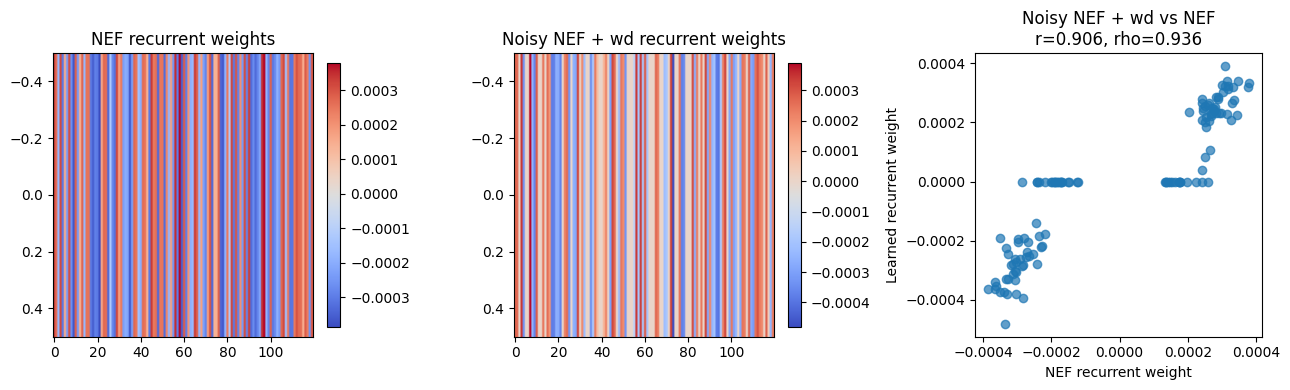

Weight decay input-weight stats:
  r=0.8481, rho=0.8459, cos=0.8480, sign=97.50%
Weight decay recurrent-weight stats:
  r=0.9060, rho=0.9356, cos=0.9059, sign=89.17%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

im0 = axes[0].imshow(ref_rec_w, aspect='auto', cmap='coolwarm')
axes[0].set_title('NEF recurrent weights')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(wd_result['post_rec_w'], aspect='auto', cmap='coolwarm')
axes[1].set_title('Noisy NEF + wd recurrent weights')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].scatter(ref_rec_w.reshape(-1), wd_result['post_rec_w'].reshape(-1), alpha=0.7)
axes[2].set_title(
    'Noisy NEF + wd vs NEF\n'
    f"r={wd_result['rec_stats']['pearson']:.3f}, rho={wd_result['rec_stats']['spearman']:.3f}"
)
axes[2].set_xlabel('NEF recurrent weight')
axes[2].set_ylabel('Learned recurrent weight')

plt.tight_layout()
plt.show()

print('Weight decay input-weight stats:')
print(
    f"  r={wd_result['input_stats']['pearson']:.4f}, "
    f"rho={wd_result['input_stats']['spearman']:.4f}, "
    f"cos={wd_result['input_stats']['cosine']:.4f}, "
    f"sign={wd_result['input_stats']['sign_agreement']:.2%}"
)
print('Weight decay recurrent-weight stats:')
print(
    f"  r={wd_result['rec_stats']['pearson']:.4f}, "
    f"rho={wd_result['rec_stats']['spearman']:.4f}, "
    f"cos={wd_result['rec_stats']['cosine']:.4f}, "
    f"sign={wd_result['rec_stats']['sign_agreement']:.2%}"
)